<a href="https://colab.research.google.com/github/Yash-k10/Machine_vision/blob/main/practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import io

plt.rcParams['figure.figsize'] = (10, 4)

Saving motion-blur.jpg to motion-blur (1).jpg


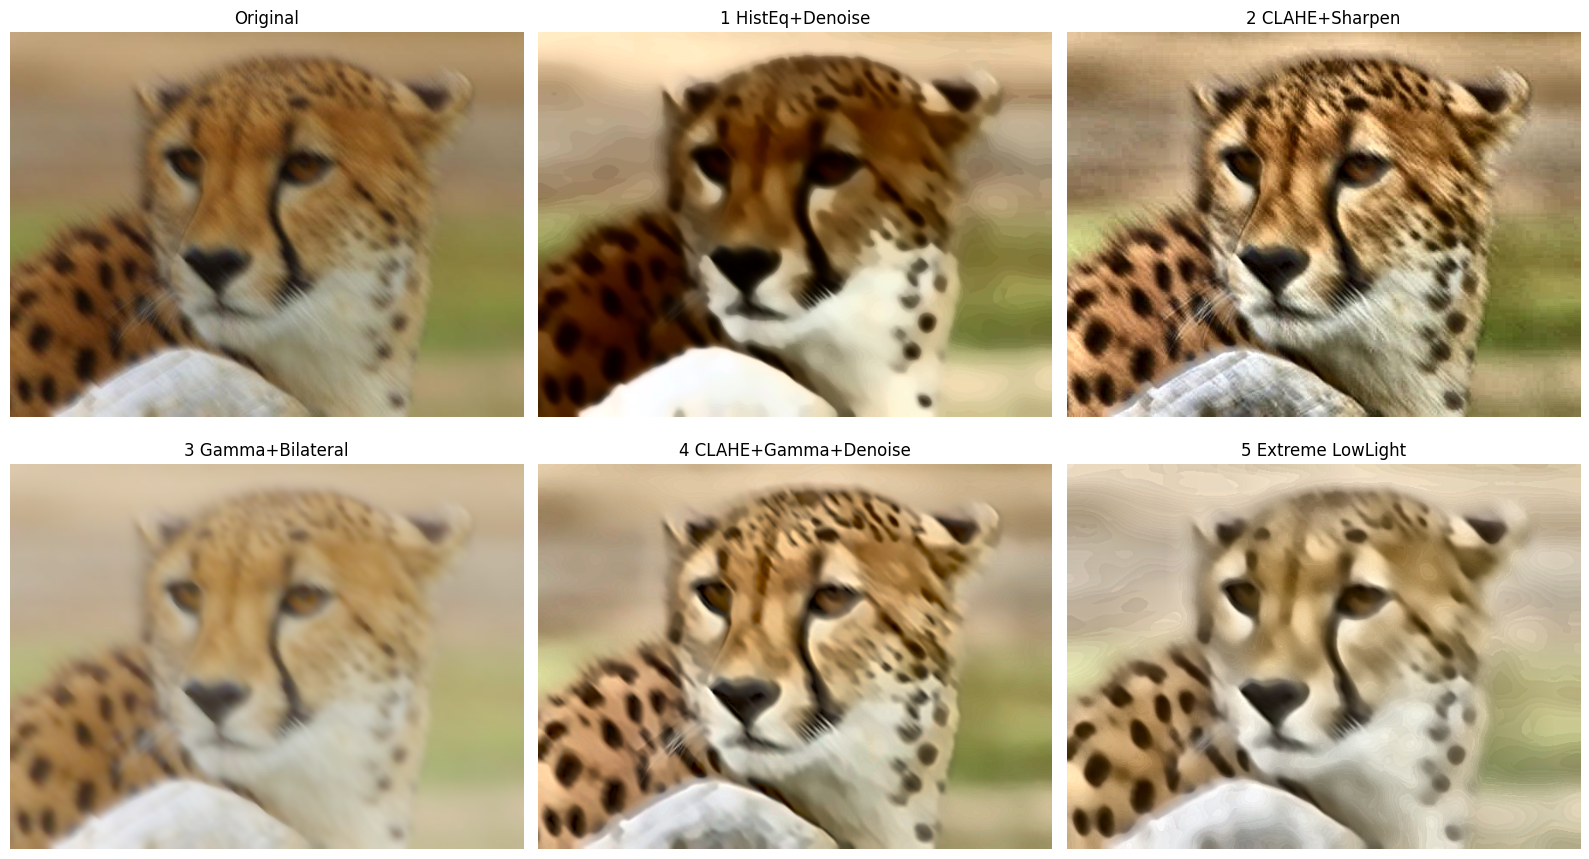

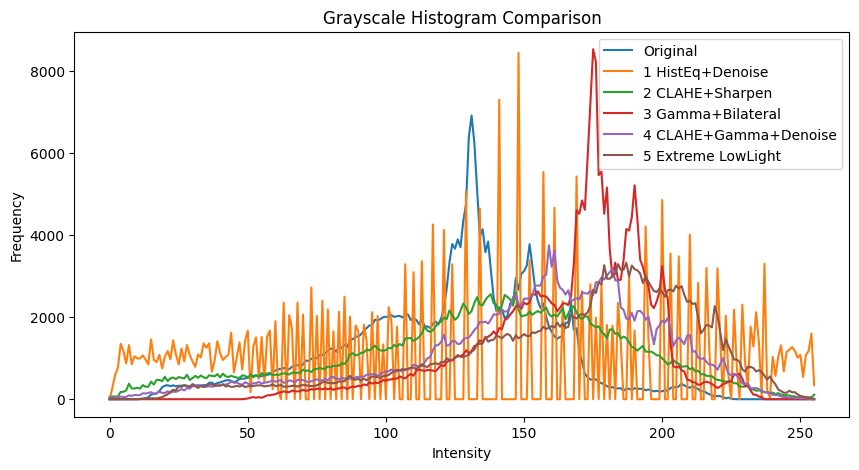

,Brightness,Contrast,Sharpness,Noise,DynamicRange
Original,121.918122,36.806932,14.387356,1.206295,215.0
1 HistEq+Denoise,128.952122,73.433986,39.593089,1.763134,254.0
2 CLAHE+Sharpen,133.980930,50.778750,243.332367,4.670888,255.0
3 Gamma+Bilateral,165.712322,30.792123,3.166507,0.550519,187.0
4 CLAHE+Gamma+Denoise,152.537330,45.963115,49.760133,2.280747,254.0
5 Extreme LowLight,165.213285,47.706870,103.674689,2.491890,249.0


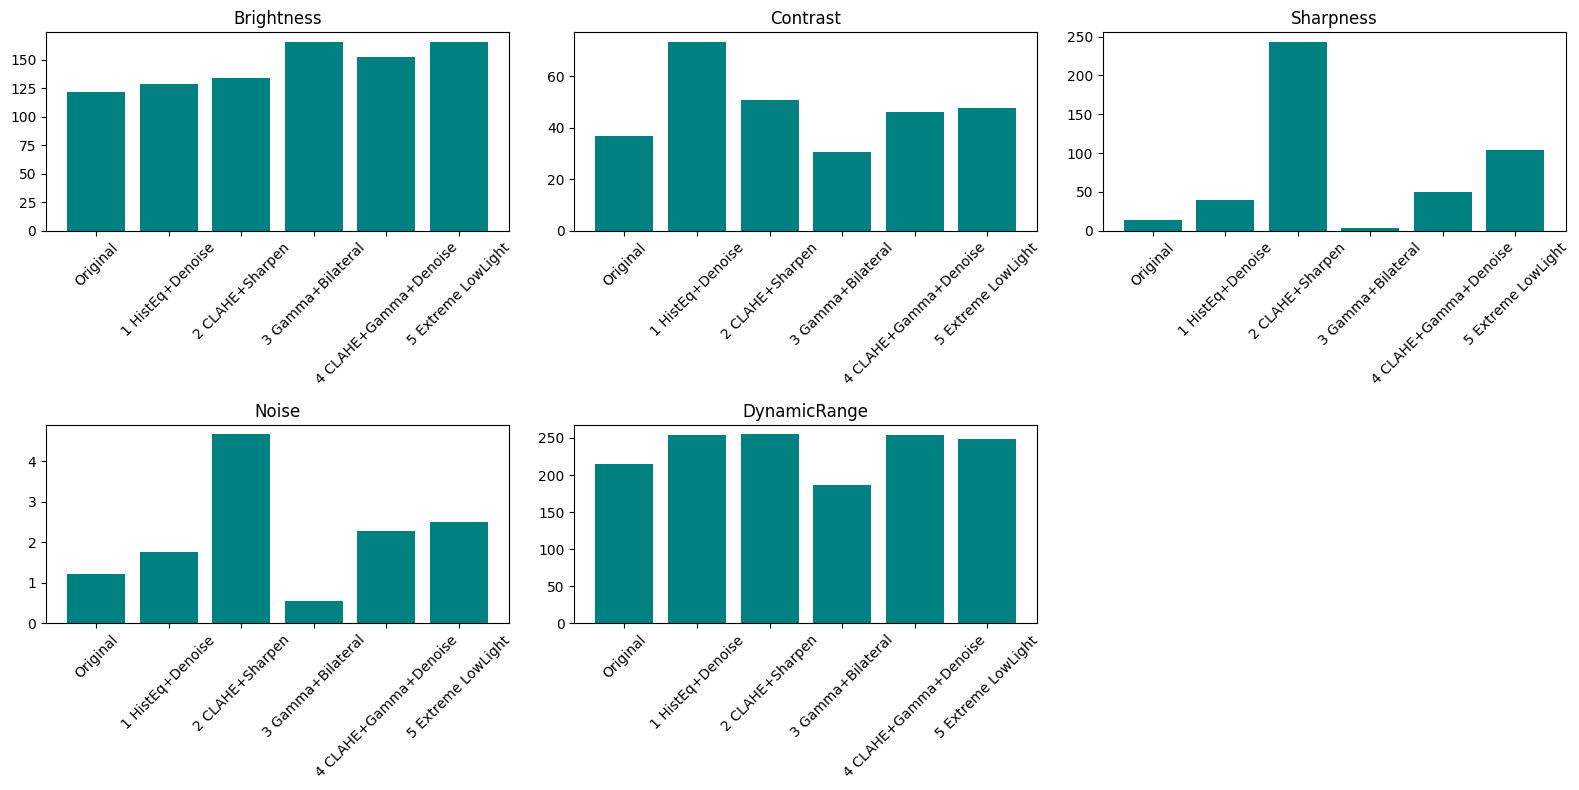

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
!pip install opencv-python-headless numpy matplotlib pandas -q

import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

# ---------- Upload ----------
up = files.upload()
img = cv2.cvtColor(np.array(Image.open(io.BytesIO(list(up.values())[0])).convert('RGB')), cv2.COLOR_RGB2BGR)

# ---------- Helper ops ----------
denoise  = lambda im, s=10: cv2.fastNlMeansDenoisingColored(im, None, s, s, 7, 21)
sharpen  = lambda im, a=1.0: cv2.addWeighted(im, 1+a, cv2.GaussianBlur(im,(0,0),3), -a, 0)
gamma    = lambda im, g=1.5: cv2.LUT(im, np.array([((i/255.0)**(1/g))*255 for i in range(256)]).astype('uint8'))
clahe_eq = lambda im, c=2.0: cv2.cvtColor(cv2.merge((cv2.createCLAHE(c,(8,8)).apply(cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2LAB))[0]), *cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2LAB))[1:])), cv2.COLOR_LAB2BGR)
hist_eq  = lambda im: cv2.cvtColor(cv2.merge((cv2.equalizeHist(cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2YCrCb))[0]), *cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2YCrCb))[1:])), cv2.COLOR_YCrCb2BGR)
bilat    = lambda im: cv2.bilateralFilter(im, 9, 75, 75)

# ---------- 5 enhancement pipelines ----------
pipelines = {
    "Original":            lambda im: im,
    "1 HistEq+Denoise":     lambda im: hist_eq(denoise(im, 7)),
    "2 CLAHE+Sharpen":      lambda im: sharpen(clahe_eq(im, 3.0), 0.6),
    "3 Gamma+Bilateral":    lambda im: bilat(gamma(im, 1.8)),
    "4 CLAHE+Gamma+Denoise":lambda im: sharpen(denoise(gamma(clahe_eq(im, 2.5), 1.3), 8), 1.0),
    "5 Extreme LowLight":   lambda im: sharpen(clahe_eq(gamma(denoise(im, 15), 2.2), 4.0), 0.8),
}
results = {name: fn(img.copy()) for name, fn in pipelines.items()}

# ---------- Display images ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, out) in zip(axes.flat, results.items()):
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

# ---------- Histograms ----------
plt.figure(figsize=(10, 5))
for name, out in results.items():
    plt.plot(cv2.calcHist([cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)], [0], None, [256], [0, 256]), label=name)
plt.title("Grayscale Histogram Comparison"); plt.xlabel("Intensity"); plt.ylabel("Frequency"); plt.legend(); plt.show()

# ---------- Analytics ----------
def metrics(im):
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).astype(np.float64)
    return {"Brightness": g.mean(), "Contrast": g.std(),
             "Sharpness": cv2.Laplacian(g, cv2.CV_64F).var(),
             "Noise": np.std(g - cv2.GaussianBlur(g, (5,5), 0)),
             "DynamicRange": g.max() - g.min()}

df = pd.DataFrame({k: metrics(v) for k, v in results.items()}).T
display(df)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, df.columns):
    ax.bar(df.index, df[col], color='teal'); ax.set_title(col); ax.tick_params(axis='x', rotation=45)
for j in range(len(df.columns), 6): fig.delaxes(axes.flat[j])
plt.tight_layout(); plt.show()

# ---------- Save & download ----------
for name, out in results.items():
    if name != "Original":
        path = f"enhanced_{name.split()[0]}.png"
        cv2.imwrite(path, out); files.download(path)

Saving blur.jpg to blur (1).jpg


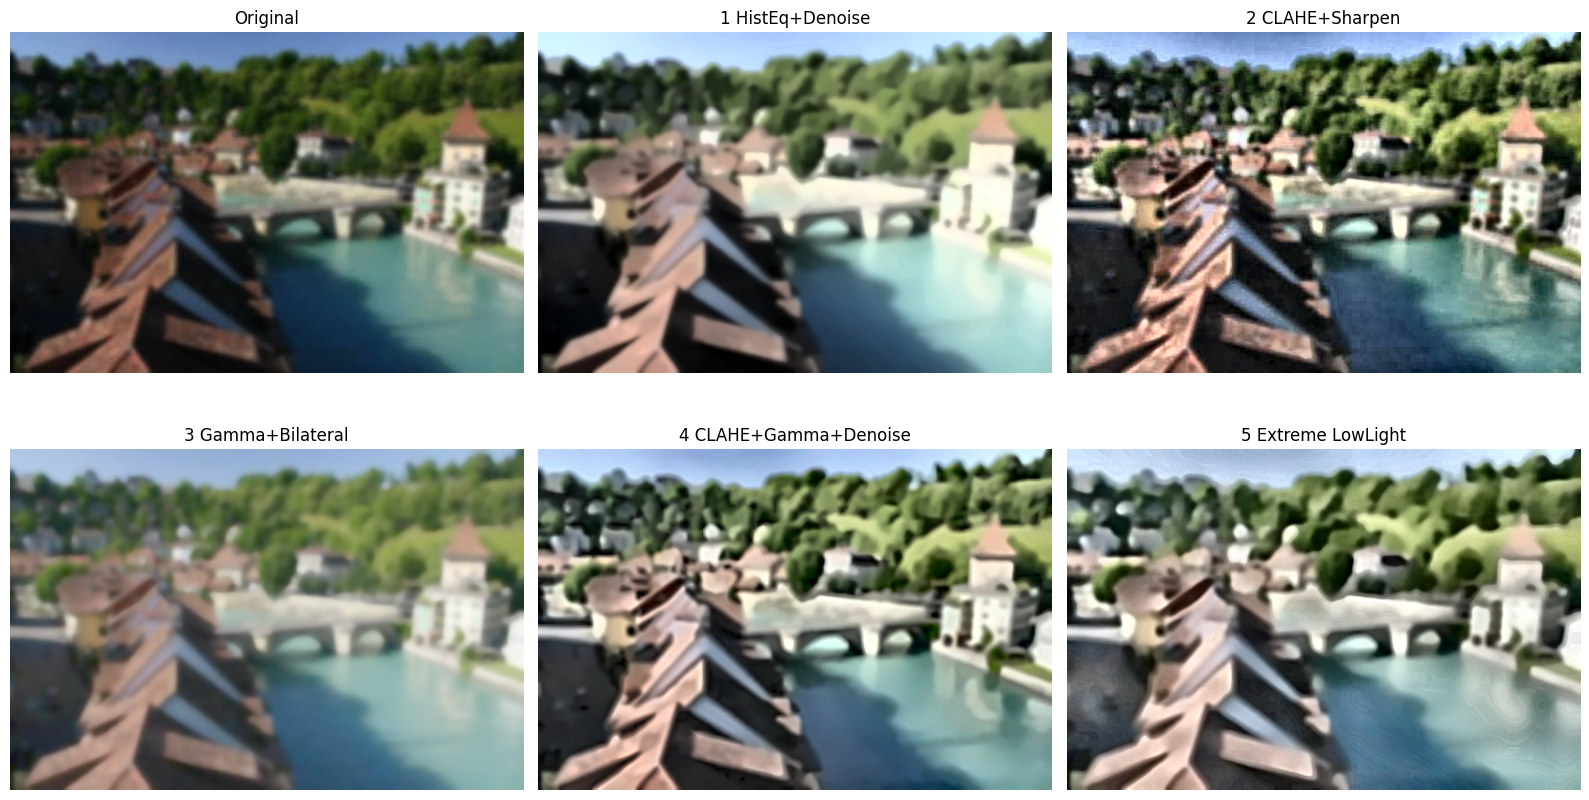

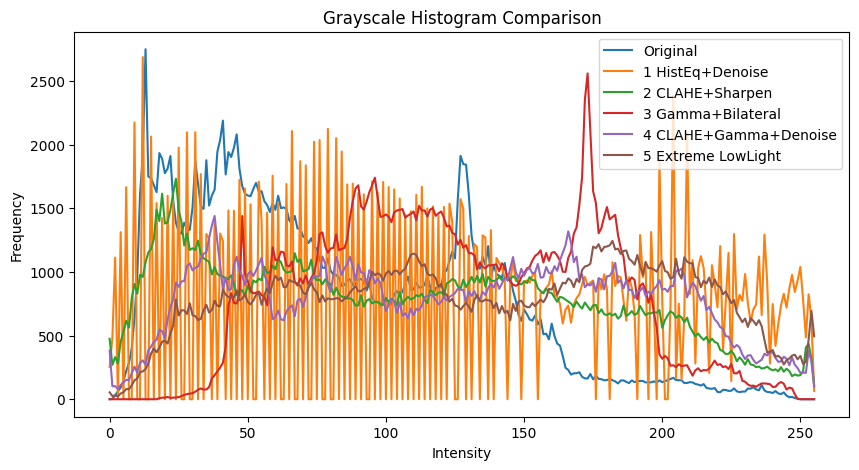

,Brightness,Contrast,Sharpness,Noise,DynamicRange
Original,79.837987,50.581930,15.570155,1.394351,248.0
1 HistEq+Denoise,128.158233,73.184353,24.582046,1.735227,255.0
2 CLAHE+Sharpen,107.086243,66.727878,211.712348,4.568128,255.0
3 Gamma+Bilateral,125.533990,47.505285,6.494094,0.936281,231.0
4 CLAHE+Gamma+Denoise,123.093422,64.856584,65.788779,2.997010,255.0
5 Extreme LowLight,133.587586,64.901602,151.771013,3.467463,255.0


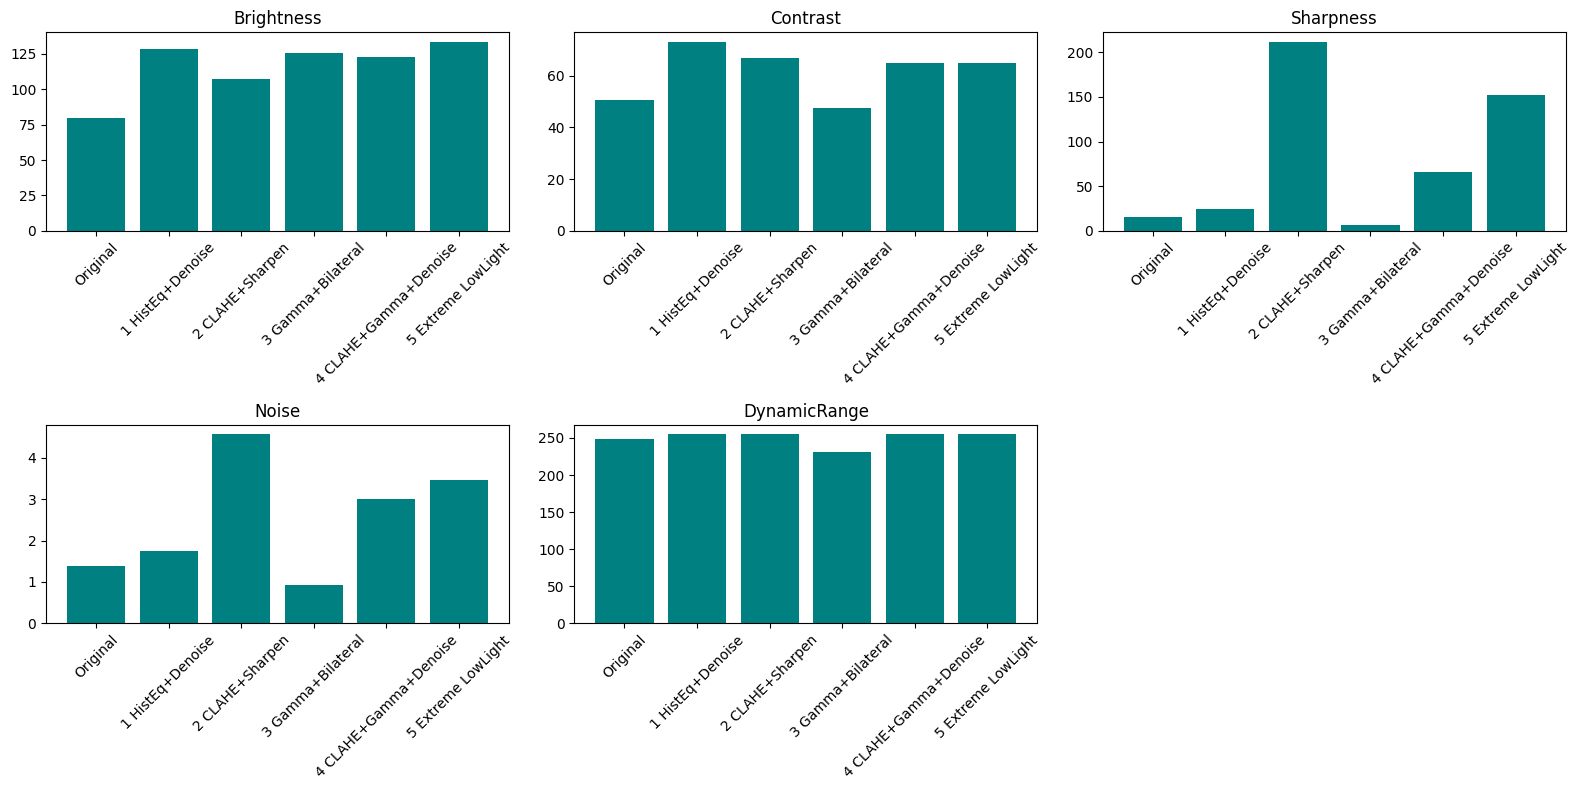

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!pip install opencv-python-headless numpy matplotlib pandas -q

import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

# ---------- Upload ----------
up = files.upload()
img = cv2.cvtColor(np.array(Image.open(io.BytesIO(list(up.values())[0])).convert('RGB')), cv2.COLOR_RGB2BGR)

# ---------- Helper ops ----------
denoise  = lambda im, s=10: cv2.fastNlMeansDenoisingColored(im, None, s, s, 7, 21)
sharpen  = lambda im, a=1.0: cv2.addWeighted(im, 1+a, cv2.GaussianBlur(im,(0,0),3), -a, 0)
gamma    = lambda im, g=1.5: cv2.LUT(im, np.array([((i/255.0)**(1/g))*255 for i in range(256)]).astype('uint8'))
clahe_eq = lambda im, c=2.0: cv2.cvtColor(cv2.merge((cv2.createCLAHE(c,(8,8)).apply(cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2LAB))[0]), *cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2LAB))[1:])), cv2.COLOR_LAB2BGR)
hist_eq  = lambda im: cv2.cvtColor(cv2.merge((cv2.equalizeHist(cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2YCrCb))[0]), *cv2.split(cv2.cvtColor(im,cv2.COLOR_BGR2YCrCb))[1:])), cv2.COLOR_YCrCb2BGR)
bilat    = lambda im: cv2.bilateralFilter(im, 9, 75, 75)

# ---------- 5 enhancement pipelines ----------
pipelines = {
    "Original":            lambda im: im,
    "1 HistEq+Denoise":     lambda im: hist_eq(denoise(im, 7)),
    "2 CLAHE+Sharpen":      lambda im: sharpen(clahe_eq(im, 3.0), 0.6),
    "3 Gamma+Bilateral":    lambda im: bilat(gamma(im, 1.8)),
    "4 CLAHE+Gamma+Denoise":lambda im: sharpen(denoise(gamma(clahe_eq(im, 2.5), 1.3), 8), 1.0),
    "5 Extreme LowLight":   lambda im: sharpen(clahe_eq(gamma(denoise(im, 15), 2.2), 4.0), 0.8),
}
results = {name: fn(img.copy()) for name, fn in pipelines.items()}

# ---------- Display images ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, out) in zip(axes.flat, results.items()):
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

# ---------- Histograms ----------
plt.figure(figsize=(10, 5))
for name, out in results.items():
    plt.plot(cv2.calcHist([cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)], [0], None, [256], [0, 256]), label=name)
plt.title("Grayscale Histogram Comparison"); plt.xlabel("Intensity"); plt.ylabel("Frequency"); plt.legend(); plt.show()

# ---------- Analytics ----------
def metrics(im):
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).astype(np.float64)
    return {"Brightness": g.mean(), "Contrast": g.std(),
             "Sharpness": cv2.Laplacian(g, cv2.CV_64F).var(),
             "Noise": np.std(g - cv2.GaussianBlur(g, (5,5), 0)),
             "DynamicRange": g.max() - g.min()}

df = pd.DataFrame({k: metrics(v) for k, v in results.items()}).T
display(df)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, df.columns):
    ax.bar(df.index, df[col], color='teal'); ax.set_title(col); ax.tick_params(axis='x', rotation=45)
for j in range(len(df.columns), 6): fig.delaxes(axes.flat[j])
plt.tight_layout(); plt.show()

# ---------- Save & download ----------
for name, out in results.items():
    if name != "Original":
        path = f"enhanced_{name.split()[0]}.png"
        cv2.imwrite(path, out); files.download(path)